<a href="https://colab.research.google.com/github/ronneb/Sales_EDA/blob/main/Videogames_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Integrado — Análisis de ventas de videojuegos
## Paso 1: Carga y exploración inicial de los datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid") # Apply a consistent theme

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/games.csv')

# --- Consolidated Data Preprocessing ---
# Renombrar columnas a minúsculas
df.columns = df.columns.str.lower()

# Convertir year_of_release a entero (nullable)
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce').astype('Int64')

# User_score: TBD → NaN, luego convertir a float
df['user_score'] = df['user_score'].replace('tbd', np.nan)
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

# Calcular ventas totales
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
# --- End of Consolidated Data Preprocessing ---

print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(16715, 12)
                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0     28.96      3.77         8.45          76.0         8.0      E   
1      3.58      6.81         0.77           NaN         NaN    NaN   
2     12.76      3.79         3.29          82.0         8.3      E   
3     10.93      3.28         2.95          80.0         8.0      E   
4      8.89     10.22         1.00           NaN         NaN    NaN   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3     

## Paso 2: Preparación de los datos

In [ ]:
# The data preprocessing logic was moved to the initial data loading cell (SxPrvp4MoDCF).
# This cell now just prints the status of the preprocessed DataFrame.

print(df.dtypes)
print(df.isnull().sum())
print(df.head())

name                object
platform            object
year_of_release      Int64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score         float64
rating              object
total_sales        float64
dtype: object
name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
total_sales           0
dtype: int64
                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii 

### Comentarios sobre la preparación:
- `year_of_release` se convirtió a numérico porque originalmente viene como float con NaN.
- `user_score` contenía la cadena `"tbd"` ("to be determined") para juegos sin puntuación aún. Se reemplazó por `NaN` para poder hacer operaciones numéricas.
- `critic_score` ya era float, no requirió cambio.
- Los valores ausentes en `name`, `genre`, `rating` se dejan como NaN: no es posible imputarlos sin información adicional y son pocos en comparación al total.
- `total_sales` es la suma de las cuatro regiones para cada juego.

## Paso 3: Análisis de los datos
### 3.1 Juegos lanzados por año

/tmp/ipykernel_2159/3366378054.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=games_per_year.index, y=games_per_year.values, palette='viridis') # Using seaborn barplot


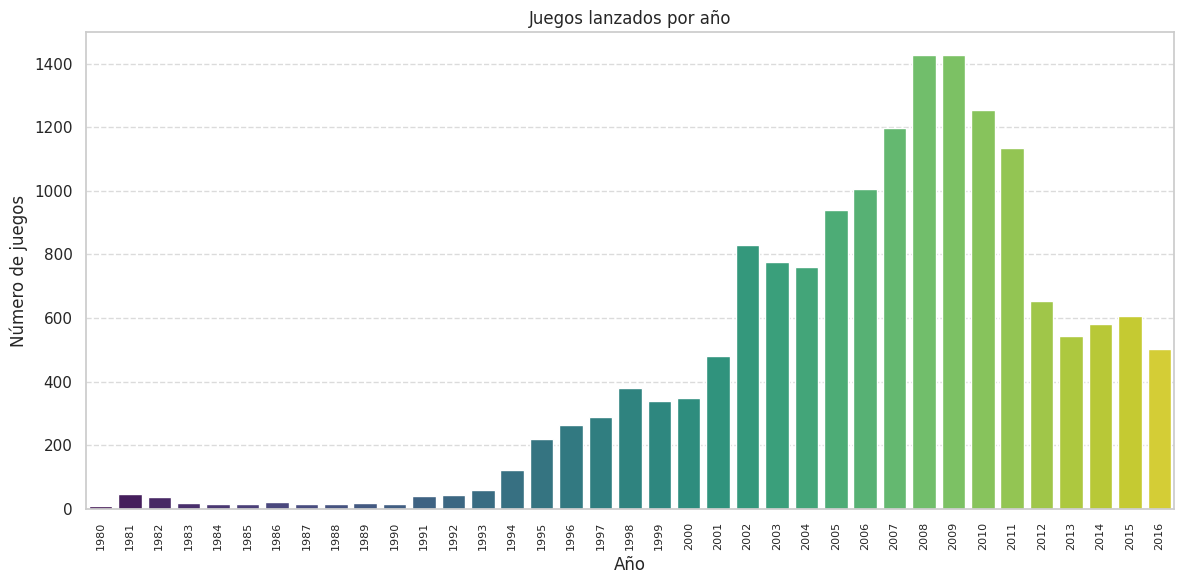

year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: name, dtype: int64


In [ ]:
games_per_year = df.groupby('year_of_release')['name'].count()

plt.figure(figsize=(12, 6)) # Adjusted figure size
sns.barplot(x=games_per_year.index, y=games_per_year.values, palette='viridis') # Using seaborn barplot
plt.title('Juegos lanzados por año')
plt.xlabel('Año')
plt.ylabel('Número de juegos')
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid
plt.tight_layout()
plt.show()

print(games_per_year)

Los datos antes de 1994 son muy escasos y poco representativos. A partir de 2000 hay volumen suficiente para análisis. El pico está entre 2007 y 2010. Los datos de 2016 parecen incompletos (el año no había terminado al recopilar el dataset).

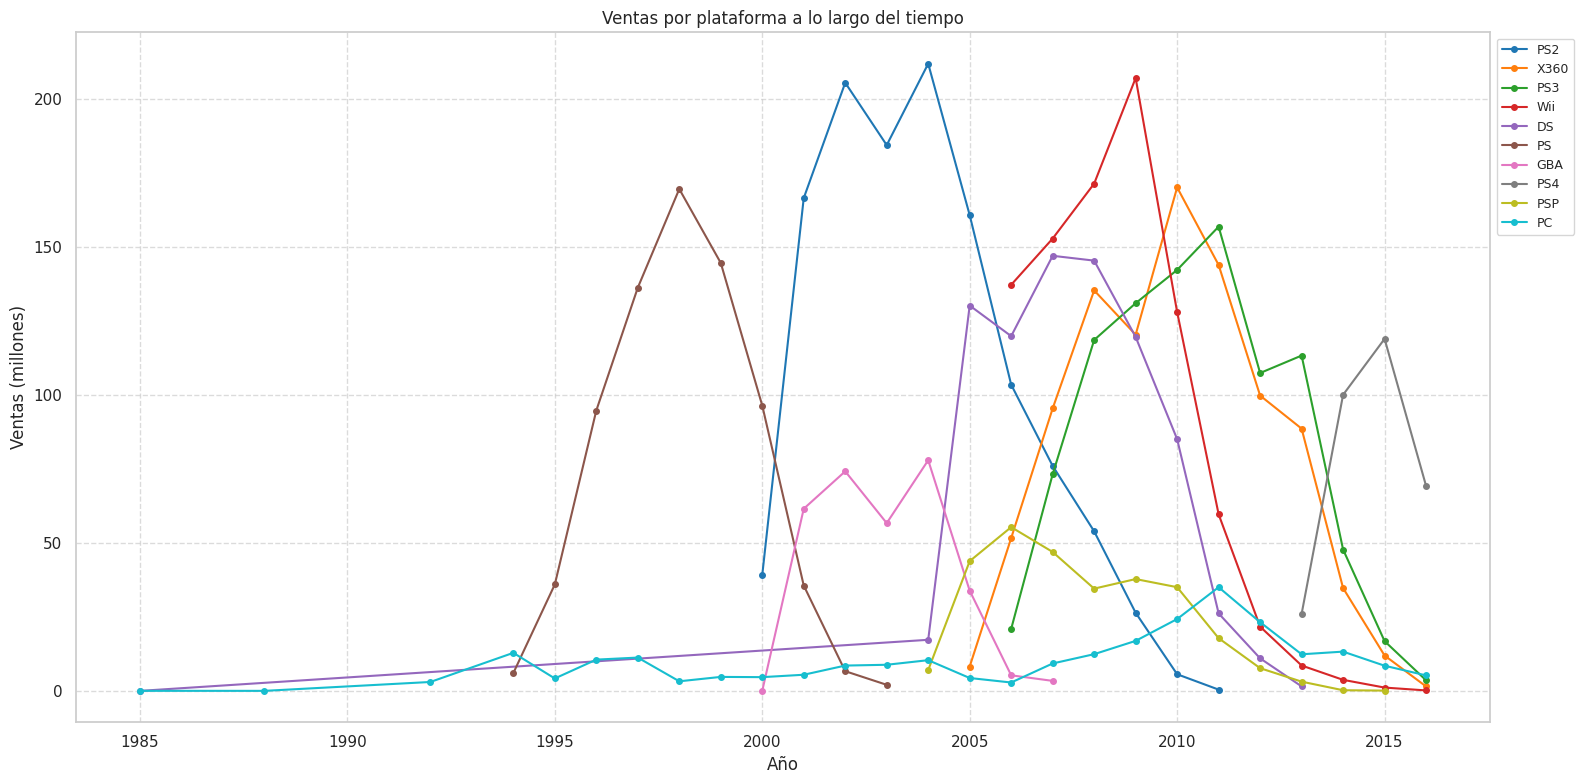

In [ ]:
# Ventas totales por plataforma y año
platform_year = df.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()

# Top 10 plataformas históricas
top_platforms = df.groupby('platform')['total_sales'].sum().nlargest(10).index

df_top = platform_year[platform_year['platform'].isin(top_platforms)]

plt.figure(figsize=(16, 8)) # Adjusted figure size for more lines

palette = sns.color_palette("tab10", len(top_platforms)) # Use a color palette
for i, platform in enumerate(top_platforms):
    data = df_top[df_top['platform'] == platform]
    plt.plot(data['year_of_release'], data['total_sales'], label=platform, color=palette[i], marker='o', markersize=4) # Added markers

plt.title('Ventas por plataforma a lo largo del tiempo')
plt.xlabel('Año')
plt.ylabel('Ventas (millones)')
plt.legend(loc='upper left', fontsize=9, bbox_to_anchor=(1, 1)) # Moved legend outside plot
plt.grid(True, linestyle='--', alpha=0.7) # Add grid
plt.tight_layout()
plt.show()

### 3.2 Período relevante para el análisis
Las plataformas tienen ciclos de vida de aproximadamente **5–7 años**. Para predecir 2017, usaremos datos de **2012 a 2016**, que reflejan el mercado actual.

In [ ]:
# Filtrar datos relevantes
df_recent = df[df['year_of_release'] >= 2012].copy()
print(df_recent.shape)

(2886, 12)


/tmp/ipykernel_2159/3448234754.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=platform_sales_recent.index, y=platform_sales_recent.values, palette='viridis') # Using seaborn barplot


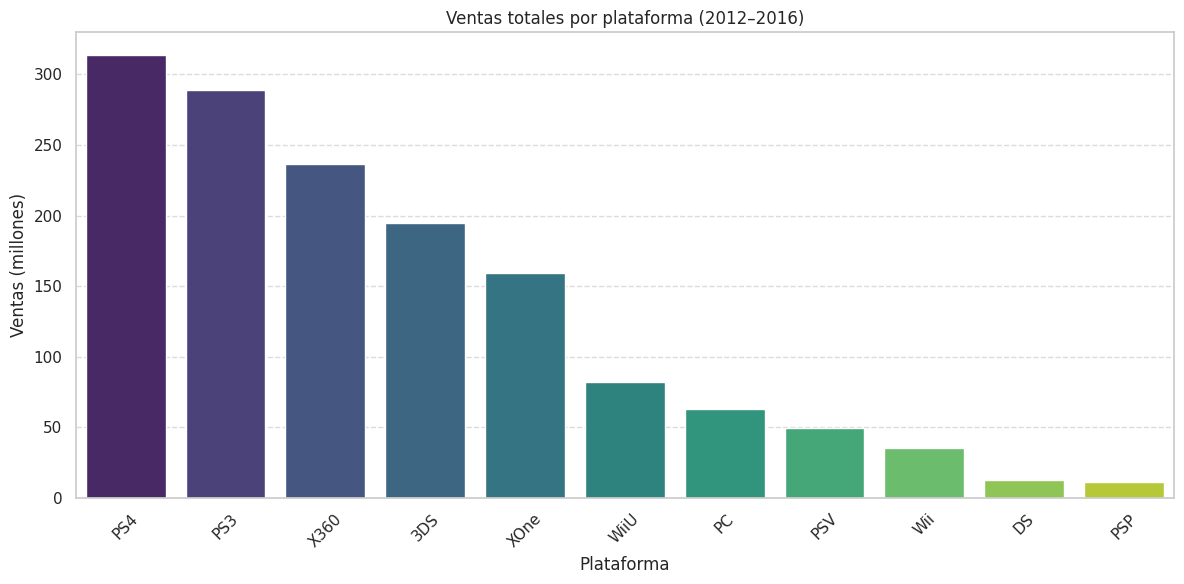

platform
PS4     314.14
PS3     288.79
X360    236.54
3DS     194.61
XOne    159.32
WiiU     82.19
PC       62.65
PSV      49.18
Wii      35.37
DS       12.55
PSP      11.19
Name: total_sales, dtype: float64


In [ ]:
platform_sales_recent = df_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6)) # Adjusted figure size
sns.barplot(x=platform_sales_recent.index, y=platform_sales_recent.values, palette='viridis') # Using seaborn barplot
plt.title('Ventas totales por plataforma (2012–2016)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas (millones)')
plt.xticks(rotation=45) # Rotate x-axis labels
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid
plt.tight_layout()
plt.show()

print(platform_sales_recent)

/tmp/ipykernel_2159/1937372050.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='platform', y='total_sales', data=df_box, palette='magma') # Using seaborn boxplot


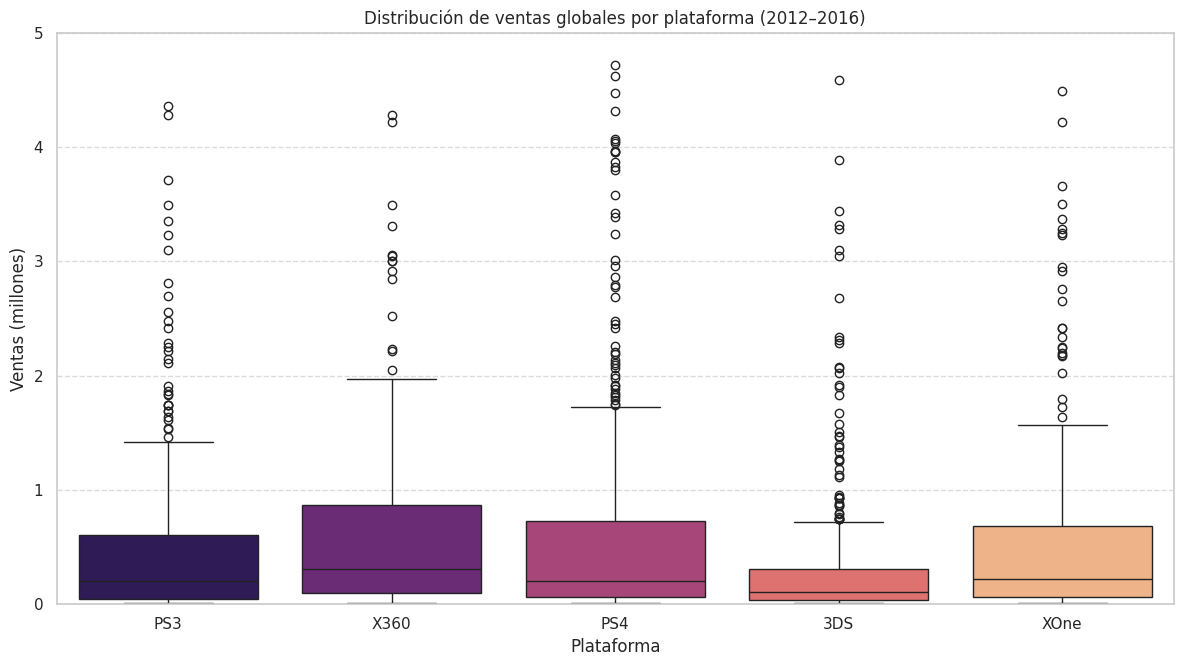

In [ ]:
top5_recent = platform_sales_recent.nlargest(5).index

df_box = df_recent[df_recent['platform'].isin(top5_recent)]

plt.figure(figsize=(12, 7)) # Adjusted figure size
sns.boxplot(x='platform', y='total_sales', data=df_box, palette='magma') # Using seaborn boxplot
plt.title('Distribución de ventas globales por plataforma (2012–2016)')
plt.suptitle('') # Remove default suptitle from boxplot
plt.xlabel('Plataforma')
plt.ylabel('Ventas (millones)')
plt.ylim(0, 5)   # limitar eje Y para mejor visualización
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid
plt.tight_layout()
plt.show()

La mayoría de los juegos venden menos de 1 millón de unidades incluso en plataformas líderes. Los outliers representan los títulos superventas. PS4 y XOne tienen distribuciones similares; 3DS domina en Japón.

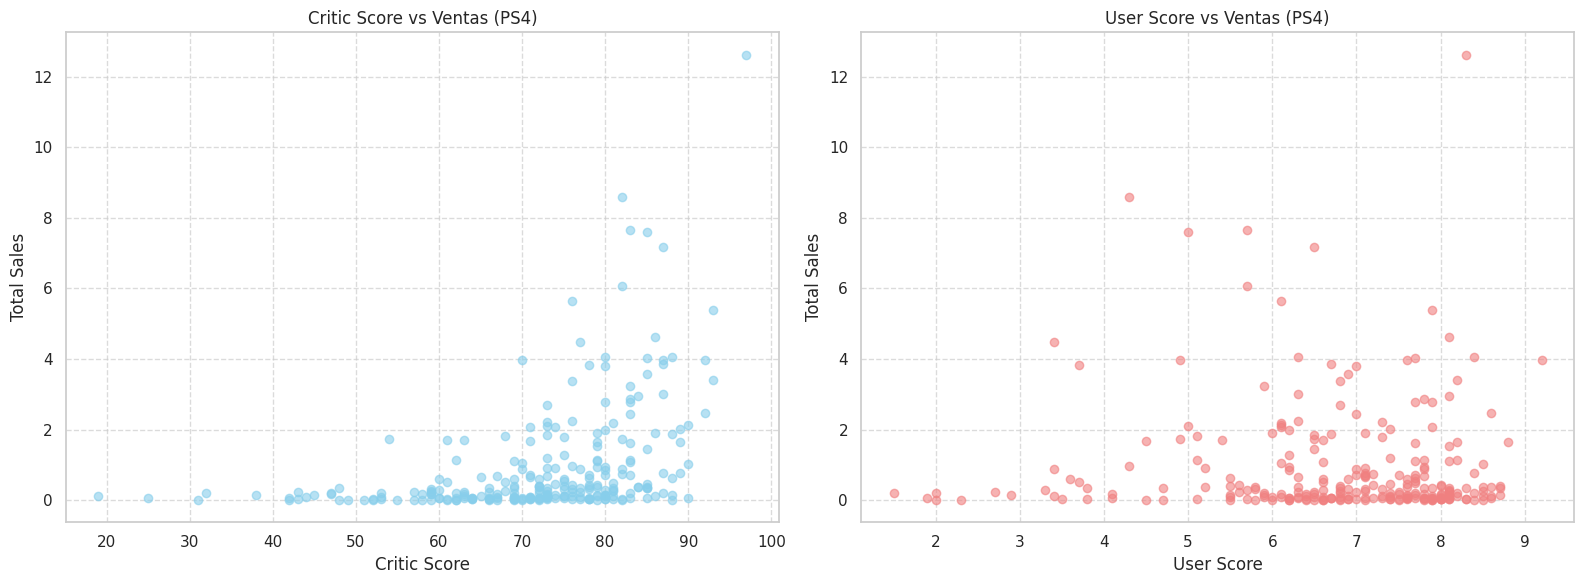

Correlación Critic Score - Ventas: 0.406
Correlación User Score - Ventas: -0.034


In [ ]:
df_ps4 = df_recent[df_recent['platform'] == 'PS4'].dropna(subset=['critic_score', 'user_score', 'total_sales'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Adjusted figure size

axes[0].scatter(df_ps4['critic_score'], df_ps4['total_sales'], alpha=0.6, color='skyblue') # Added color and adjusted alpha
axes[0].set_title('Critic Score vs Ventas (PS4)')
axes[0].set_xlabel('Critic Score')
axes[0].set_ylabel('Total Sales')
axes[0].grid(True, linestyle='--', alpha=0.7) # Add grid

axes[1].scatter(df_ps4['user_score'], df_ps4['total_sales'], alpha=0.6, color='lightcoral') # Added color and adjusted alpha
axes[1].set_title('User Score vs Ventas (PS4)')
axes[1].set_xlabel('User Score')
axes[1].set_ylabel('Total Sales')
axes[1].grid(True, linestyle='--', alpha=0.7) # Add grid

plt.tight_layout()
plt.show()

corr_critic = df_ps4['critic_score'].corr(df_ps4['total_sales'])
corr_user = df_ps4['user_score'].corr(df_ps4['total_sales'])
print(f'Correlación Critic Score - Ventas: {corr_critic:.3f}')
print(f'Correlación User Score - Ventas: {corr_user:.3f}')

Hay una correlación moderada entre `critic_score` y ventas (típicamente 0.3–0.5), lo que sugiere que las reseñas de expertos tienen algo de influencia pero no son determinantes. La correlación con `user_score` suele ser menor.

/tmp/ipykernel_2159/3380144715.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='viridis') # Using seaborn barplot


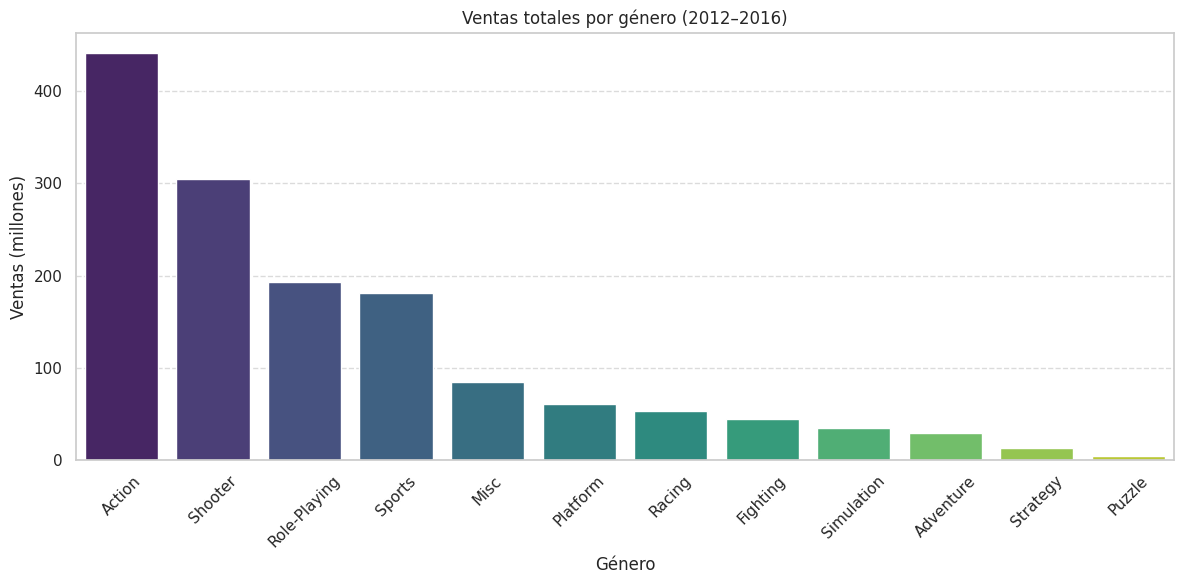

genre
Action          441.12
Shooter         304.73
Role-Playing    192.80
Sports          181.07
Misc             85.04
Platform         61.00
Racing           53.50
Fighting         44.49
Simulation       35.12
Adventure        29.43
Strategy         13.34
Puzzle            4.89
Name: total_sales, dtype: float64


In [ ]:
genre_sales = df_recent.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6)) # Adjusted figure size
sns.barplot(x=genre_sales.index, y=genre_sales.values, palette='viridis') # Using seaborn barplot
plt.title('Ventas totales por género (2012–2016)')
plt.xlabel('Género')
plt.ylabel('Ventas (millones)')
plt.xticks(rotation=45) # Rotate x-axis labels
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid
plt.tight_layout()
plt.show()

print(genre_sales)

## Paso 4: Perfil de usuario por región

In [ ]:
regions = {'NA': 'na_sales', 'EU': 'eu_sales', 'JP': 'jp_sales'}

for region, col in regions.items():
    print(f'\n=== {region} ===')

    # Top 5 plataformas
    top_plat = df_recent.groupby('platform')[col].sum().nlargest(5)
    print('Top 5 plataformas:')
    print(top_plat)

    # Top 5 géneros
    top_genre = df_recent.groupby('genre')[col].sum().nlargest(5)
    print('\nTop 5 géneros:')
    print(top_genre)

    # ESRB vs ventas
    esrb = df_recent.groupby('rating')[col].sum().sort_values(ascending=False)
    print('\nVentas por rating ESRB:')
    print(esrb)


=== NA ===
Top 5 plataformas:
platform
X360    140.05
PS4     108.74
PS3     103.38
XOne     93.12
3DS      55.31
Name: na_sales, dtype: float64

Top 5 géneros:
genre
Action          177.84
Shooter         144.77
Sports           81.53
Role-Playing     64.00
Misc             38.19
Name: na_sales, dtype: float64

Ventas por rating ESRB:
rating
M       231.57
E       114.37
E10+     75.70
T        66.02
Name: na_sales, dtype: float64

=== EU ===
Top 5 plataformas:
platform
PS4     141.09
PS3     106.86
X360     74.52
XOne     51.59
3DS      42.64
Name: eu_sales, dtype: float64

Top 5 géneros:
genre
Action          159.34
Shooter         113.47
Sports           69.09
Role-Playing     48.53
Racing           27.29
Name: eu_sales, dtype: float64

Ventas por rating ESRB:
rating
M       193.96
E       113.03
E10+     55.37
T        52.96
Name: eu_sales, dtype: float64

=== JP ===
Top 5 plataformas:
platform
3DS     87.79
PS3     35.29
PSV     21.04
PS4     15.96
WiiU    13.01
Name: jp_sales, 

**Observaciones:**
- En **NA** y **EU** dominan PS4 y XOne; en **JP** domina 3DS, lo que refleja la preferencia por handhelds en Japón.
- Los géneros de **Acción** y **Deportes** lideran en NA/EU; en JP prefieren **Role-Playing**.
- La clasificación **M (Mature)** tiene ventas altas en NA, pero en JP los juegos **E y T** son más relevantes.

## Paso 5: Prueba de hipótesis

### Hipótesis 1: ¿Son iguales las puntuaciones de usuarios en Xbox One y PC?
- **H₀:** La puntuación promedio de usuarios de Xbox One = PC  
- **H₁:** Son diferentes  
- Usamos **t-test de dos muestras independientes** (prueba paramétrica, datos continuos, grupos independientes).
- Umbral α = 0.05

In [ ]:
xone_scores = df[df['platform'] == 'XOne']['user_score'].dropna()
pc_scores   = df[df['platform'] == 'PC']['user_score'].dropna()

t_stat, p_value = stats.ttest_ind(xone_scores, pc_scores)

print(f'XOne — media: {xone_scores.mean():.2f}, n={len(xone_scores)}')
print(f'PC   — media: {pc_scores.mean():.2f}, n={len(pc_scores)}')
print(f'\nt-statistic: {t_stat:.4f}')
print(f'p-value: {p_value:.4f}')

if p_value < 0.05:
    print('\nRechazamos H₀: hay diferencia significativa entre las medias.')
else:
    print('\nNo rechazamos H₀: no hay evidencia suficiente de diferencia.')

XOne — media: 6.52, n=182
PC   — media: 7.06, n=770

t-statistic: -4.3683
p-value: 0.0000

Rechazamos H₀: hay diferencia significativa entre las medias.


### Hipótesis 2: ¿Son diferentes las puntuaciones de Acción y Deportes?
- **H₀:** Puntuación promedio de Acción = Deportes  
- **H₁:** Son diferentes  
- Mismo criterio: t-test de dos muestras independientes, α = 0.05

In [ ]:
action_scores = df[df['genre'] == 'Action']['user_score'].dropna()
sports_scores = df[df['genre'] == 'Sports']['user_score'].dropna()

t_stat2, p_value2 = stats.ttest_ind(action_scores, sports_scores)

print(f'Acción  — media: {action_scores.mean():.2f}, n={len(action_scores)}')
print(f'Deportes — media: {sports_scores.mean():.2f}, n={len(sports_scores)}')
print(f'\nt-statistic: {t_stat2:.4f}')
print(f'p-value: {p_value2:.4f}')

if p_value2 < 0.05:
    print('\nRechazamos H₀: las medias son significativamente diferentes.')
else:
    print('\nNo rechazamos H₀: no hay diferencia significativa.')

Acción  — media: 7.05, n=1830
Deportes — media: 6.96, n=1103

t-statistic: 1.6259
p-value: 0.1041

No rechazamos H₀: no hay diferencia significativa.


## Paso 6: Conclusión general

### Datos y preparación
El dataset contiene 16,715 juegos. Se encontraron valores ausentes significativos en
`critic_score` (8,578), `user_score` (9,125) y `rating` (6,766), principalmente porque
muchos juegos antiguos no tienen reseñas registradas. Los valores `tbd` en `user_score`
fueron tratados como NaN. Se usaron datos de **2012 a 2016** para el análisis relevante,
ya que las plataformas tienen ciclos de vida de ~5–7 años.

---

### Mercado general (2012–2016)
- **PS4** lidera con 314M en ventas totales, seguida de PS3 (288M) y X360 (236M).
- **3DS** domina en Japón con 87M, mientras que en NA y EU es menos relevante.
- XOne y WiiU muestran ventas en crecimiento y declive respectivamente.
- El promedio de ventas por juego en PS4 es 0.80M y en X360 es 0.81M — los más altos.
  La mediana es ~0.20M, lo que confirma que los superventas distorsionan el promedio.

---

### Géneros
- **Acción** (441M) y **Shooter** (304M) dominan globalmente.
- **Role-Playing** es el segundo género en Japón (65M), mientras que en NA apenas figura.
- **Puzzle** y **Strategy** son los géneros menos rentables.

---

### Reseñas vs. ventas (PS4)
- La correlación entre `critic_score` y ventas es **0.406** — moderada y positiva.
  Los juegos mejor valorados por críticos tienden a vender más, pero no es determinante.
- La correlación entre `user_score` y ventas es **-0.034** — prácticamente nula.
  Las opiniones de usuarios no predicen las ventas.

---

### Perfil regional
| Región | Plataforma líder | Género líder | Rating más vendido |
|--------|-----------------|--------------|-------------------|
| NA | X360 / PS4 | Acción / Shooter | M (Mature) |
| EU | PS4 / PS3 | Acción / Shooter | M (Mature) |
| JP | 3DS | Role-Playing | E / T |

Japón tiene un perfil completamente diferente: prefiere handhelds (3DS, PSV),
juegos de rol y ratings más accesibles (E y T). NA y EU son más similares entre sí.

---

### Pruebas de hipótesis (α = 0.05)

**Hipótesis 1 — XOne vs PC (user_score):**
- H₀: las medias son iguales. H₁: son diferentes.
- XOne: media = 6.52 | PC: media = 7.06
- t = -4.37, **p = 0.000** → **Rechazamos H₀**.
- Hay diferencia estadísticamente significativa: los usuarios valoran más los juegos de PC.

**Hipótesis 2 — Acción vs Deportes (user_score):**
- H₀: las medias son iguales. H₁: son diferentes.
- Acción: media = 7.05 | Deportes: media = 6.96
- t = 1.63, **p = 0.104** → **No rechazamos H₀**.
- No hay evidencia suficiente de que los usuarios valoren diferente ambos géneros.

---

### Recomendaciones para la campaña 2017
1. Priorizar **PS4** en NA y EU, y **3DS** en Japón.
2. Invertir en publicidad de juegos de **Acción y Shooter** para mercados occidentales.
3. Para Japón, apostar por **Role-Playing** en plataformas portátiles.
4. Las reseñas de críticos importan: buscar títulos con `critic_score` alto (>75).
5. En NA y EU, los juegos con rating **M** generan más ventas totales.